# Набор данных по полетам между аэропортами

Нужно выбрать две задачи из списка, одну про выделение сообществ и одну по мерам центральности или кластерности. Задания прописаны [здесь](https://disk.360.yandex.ru/i/sieyfvgTyrAhBg). Не забываем прописать в таблице состав команды и выполняемые задания.  
Требуется прочитать граф из файла `data/openflights.txt`, вычислить выбранные метрики, вывести результат в csv-файл в формате  
Airport ID, label  
идентификатор аэропорта, вычисленное значение показателя или номер сообщества  
Пример выходных данных приведен в `airport_indexes.csv`.  
Загружаем код и результирующие файлы в облако [Classroom](https://clck.ru/3TAdZz), прописываем к ним доступ, добавляем ссылки на код и данные в файл с заданиями. 2 минуты на представление результатов коллегам.  


In [ ]:
import pandas as pd
import plotly.express as px
import networkx as nx
import community as community_louvain
import matplotlib.cm as cm
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('openflights.txt', sep=' ')
df.columns = ['source', 'target', 'weight']
df.head()


,source,target,weight
0,2,4,1
1,2,5,1
2,2,6,2
3,2,5430,1
4,3,2,1


рассчитываем сообщества по алгоритму

/tmp/ipykernel_3851/1119282574.py:6: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



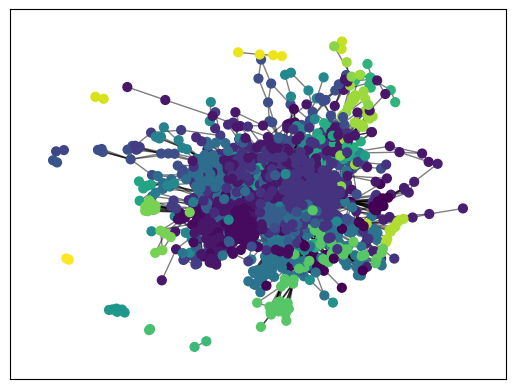

In [25]:
G = nx.from_pandas_edgelist(df, source='source', target='target', edge_attr='weight')

partition = community_louvain.best_partition(G, weight='weight')

pos = nx.spring_layout(G)
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=40,
                       cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

pd.DataFrame(partition.items(), columns=['Airport ID', 'label']).to_csv('airport_indexes.csv', index=False)

визуализируем на карте мира

In [26]:
cities = pd.read_csv("openflights_airports.txt", delimiter=" ")
air_res = pd.read_csv("airport_indexes.csv")

cities2 = air_res.merge(cities, how='left', on="Airport ID")
cities2['community'] = cities2.index.map(partition)

# Визуализация на карте
fig = px.scatter_map(cities2, lat="Latitude", lon="Longitude", color="community",
                     map_style="open-street-map", color_continuous_scale=px.colors.sequential.Rainbow,
                     zoom=0.5, width=900, height=600)
fig.update_layout(showlegend=False)
fig.show()

In [18]:
closeness = nx.closeness_centrality(G)

closeness_df = pd.DataFrame(
    closeness.items(),
    columns=['airport', 'closeness_centrality']
).sort_values('closeness_centrality', ascending=False)

print("Airport Closeness Centrality:")
print(closeness_df)

most_central = closeness_df.iloc[0]
print(f"\nMost central airport: {most_central['airport']} (score: {most_central['closeness_centrality']:.4f})")

Airport Closeness Centrality:
      airport  closeness_centrality
52        340              0.401005
64       1382              0.393636
56        507              0.392130
58        580              0.387786
307      2188              0.385236
...       ...                   ...
2900     6448              0.000340
2901     6449              0.000340
2861     4058              0.000340
2863     5745              0.000340
2864     7063              0.000340

[2939 rows x 2 columns]

Most central airport: 340.0 (score: 0.4010)


In [20]:
closeness_df.to_csv('airport_centrality.csv')

# Набор данных с взаимодействием персонажей фанфиков по Гарри Поттеру

Нужно выбрать две задачи из списка, одну про выделение сообществ и одну по мерам центральности или кластерности, но не те, что были в первой части. Задания прописаны [здесь](https://disk.360.yandex.ru/i/sieyfvgTyrAhBg). Не забываем прописать в таблице состав команды и выполняемые задания.  
Требуется прочитать граф из файла `data/hp_data3.txt`, вычислить выбранные метрики, вывести результат в csv-файл в формате  
name, size, color  
имя персонажа, размер соответствующей ему вершины, цвет соответствующей ему вершины  
Пример выходных данных приведен в `hp_results.csv`.  
Загружаем код и результирующие файлы в облако [Classroom](https://clck.ru/3TAdZz), прописываем к ним доступ, добавляем ссылки на код и данные в файл с заданиями. 2 минуты на представление результатов коллегам.  

In [28]:
!pip install igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 71.4 MB/s eta 0:00:00


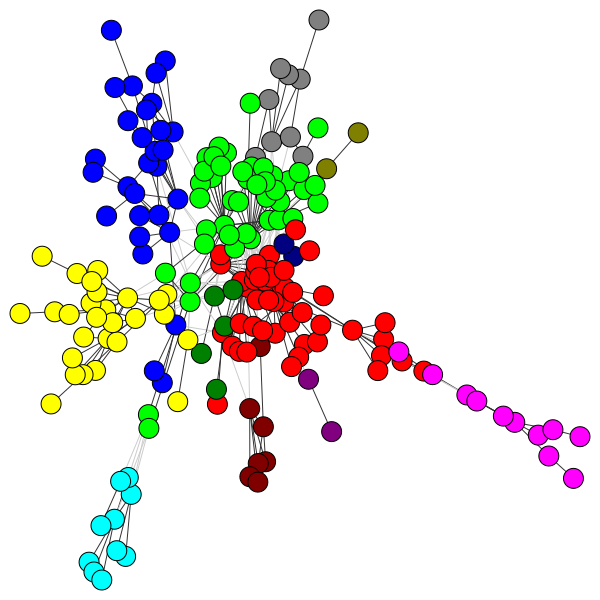

In [36]:
import igraph as ig
import leidenalg as la


df_hp = pd.read_csv('hp_data3.csv')
edges = list(zip(df_hp['entity1'], df_hp['entity2']))
G_ig = ig.Graph.TupleList(edges, directed=False)
G_ig.es['weight'] = df_hp['freq'].values

partition = la.find_partition(
    G_ig,
    la.RBConfigurationVertexPartition,
    weights='weight',
    seed=42
)

ig.plot(partition)

In [41]:
G_nx = nx.Graph()
for _, row in df_hp.iterrows():
    G_nx.add_edge(row['entity1'], row['entity2'], weight=row['freq'])

centrality = nx.eigenvector_centrality(G_nx)
centrality_df = pd.DataFrame(
    centrality.items(),
    columns=['name', 'size']
).sort_values('size', ascending=False)

print("HP eigenvector Centrality:")
print(centrality_df)

centrality_df.to_csv('hp_results.csv')

HP eigenvector Centrality:
          name          size
2        драко  3.074062e-01
8       малфой  3.069071e-01
1     гермиона  2.737108e-01
24      забини  2.452252e-01
23       блейз  2.440961e-01
..         ...           ...
74   мальсибер  2.492073e-06
112  рудольфус  2.492073e-06
68       ойген  2.479538e-06
75      эйвери  1.766903e-07
158       руди  1.766903e-07

[193 rows x 2 columns]
